In [1]:
import torch
import torchcde
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Subset, Dataset,random_split
from torchvision.datasets import DatasetFolder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

n_sensors=13
epochs=20
batch_size=1
lr=1e-4
spf = 0.1  # reciprocal of frames per second
fc_hidden=128
accumulation_steps = 8
eps = 1e-6

In [2]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(42)

In [4]:
raw_df = pd.read_csv("E:/CoDaS Project/Radar/C3/radar_merged_data.csv")
decimals=1
raw_df['timestamp'] = raw_df['timestamp'].round(decimals)  # Round timestamps to the specified number of decimal places for consistency

In [5]:
le = LabelEncoder()
le.fit(raw_df['emotion'].unique())
n_classes = len(le.classes_)

In [39]:
unique_users = raw_df['user_id'].unique()
train_users, test_users = train_test_split(unique_users, test_size=int(0.2*(len(unique_users))), random_state=42)
train_users, valid_users = train_test_split(train_users, test_size=int(0.2*(len(unique_users))), random_state=42)
train_df, test_df = raw_df[raw_df['user_id'].isin(train_users)], raw_df[raw_df['user_id'].isin(test_users)]
valid_df = raw_df[raw_df['user_id'].isin(valid_users)]

#train_df.set_index(['user_id','emotion'], inplace=True)
#test_df.set_index(['user_id','emotion'], inplace=True)

In [7]:
def compute_delta_t(times, mask):
    T, S = mask.shape
    delta_t = np.full((T, S), np.nan, dtype=float)

    last_obs_time = np.full(S, np.nan)

    for t in range(T):
        observed = mask[t].astype(bool)

        # Reset timer for observed sensors
        delta_t[t, observed] = 0.0
        last_obs_time[observed] = times[t]

        # Compute elapsed time for missing sensors that have been seen before
        missing = ~observed
        has_previous = ~np.isnan(last_obs_time)

        valid = missing & has_previous
        delta_t[t, valid] = times[t] - last_obs_time[valid]

    return delta_t

In [51]:
def process_input_sequence(raw_sequence):
    raw_sequence = raw_sequence.sort_values("timestamp")
    # mask for each sensor: True if observed else false
    sensor_mask = raw_sequence.drop(columns=['timestamp']).notna().to_numpy()[:,::3]

    timestamps = raw_sequence["timestamp"].to_numpy()

    sensor_cols = raw_sequence.columns.drop("timestamp")
    mean_values = raw_sequence[sensor_cols].mean()
    std_values = raw_sequence[sensor_cols].std()

    # Center the sensor values by subtracting the mean and scaling by the standard deviation
    raw_sequence[sensor_cols]-= mean_values
    #raw_sequence[sensor_cols]/= (std_values + eps)

    filled_sequence = raw_sequence.ffill()

    #time_since_last_obs = compute_delta_t(timestamps, sensor_mask)

    #filled_sequence = np.concatenate([filled_sequence, sensor_mask, time_since_last_obs],axis=-1)
    filled_sequence = np.concatenate([filled_sequence, sensor_mask],axis=-1)
    filled_sequence = torch.tensor(filled_sequence, dtype=torch.float32)

    timestamps = torch.tensor(timestamps, dtype=torch.float32)

    #mean_values = torch.tensor(mean_values.values, dtype=torch.float32)
    #std_values = torch.tensor(std_values.values, dtype=torch.float32)

    return filled_sequence, timestamps, mean_values, std_values

def process_target_sequence(target_values, input_mean, input_std):
    target_values = target_values.sort_values("timestamp")
    target_timestamps = target_values['timestamp'].values

    target_values = target_values.drop(columns=['timestamp'])
    target_values = (target_values - input_mean)# / (input_std + eps)

    target_mask = target_values.notna().values

    target_values = target_values.fillna(0).values  # Fill NaN values with 0 for processing
    
    # Convert to torch tensor
    target_values = torch.tensor(target_values, dtype=torch.float32)
    target_mask = torch.tensor(target_mask, dtype=torch.bool)
    target_timestamps = torch.tensor(target_timestamps, dtype=torch.float32)
    
    return target_timestamps, target_values, target_mask

In [52]:
class RadarSequenceDataset(Dataset):
    def __init__(self, df,test=False):
        """
        Args:
            df: DataFrame with radar data
            test: Boolean indicating if the dataset is for testing
        """
        # Split data
        self.df = df
        self.experiments = df.index.unique()
        self.test = test
    
    def __len__(self):
        return len(self.experiments)
    
    def __getitem__(self, idx):
        experiment = self.experiments[idx]
        user_id, emotion = experiment
        experiment_data = self.df.loc[experiment].groupby("timestamp", as_index=False).mean()

        t_max = experiment_data["timestamp"].max()
        t_min = experiment_data["timestamp"].min()
        experiment_data["timestamp"] = (experiment_data["timestamp"] - t_min) / (t_max - t_min)  # Normalize timestamps to [0, 1]
        p = random.uniform(0.1, 0.3)
        # Split into input and target sequences
        if not self.test:
            input_sequence, target_sequence = train_test_split(experiment_data, test_size=p)
        else:
            input_sequence, target_sequence = train_test_split(experiment_data, test_size=0.2, random_state=42)

        # Process using existing function
        input_sequence, input_timestamps, input_mean, input_std = process_input_sequence(input_sequence)
        target_timestamp, target_sequence, target_mask = process_target_sequence(target_sequence, input_mean, input_std)
        
        return (input_sequence, input_timestamps), (target_timestamp, target_sequence, target_mask), emotion


# Create train and test datasets
train_dataset = RadarSequenceDataset(train_df.set_index(['user_id','emotion']))
valid_dataset = RadarSequenceDataset(valid_df.set_index(['user_id','emotion']))

test_dataset = RadarSequenceDataset(test_df.set_index(['user_id','emotion']), test=True)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=1, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [10]:
# Create model
input_channels = n_sensors*4 + 1
hidden_channels = 128  # hyperparameter, we can pick whatever we want for this
output_channels = n_sensors*3  # e.g. to perform 10-way multiclass classification
    
class CDEFunc(nn.Module):
    def __init__(self):
        super(CDEFunc, self).__init__()

        self.hidden_channels = hidden_channels
        self.input_channels = input_channels

        self.net = nn.Sequential(
            nn.Linear(hidden_channels, 128),
            nn.ReLU(),
            nn.Linear(128, hidden_channels * input_channels),
            nn.Tanh()
        )

    def forward(self, t, z):
        out = self.net(z)
        out = 1e-3 * out.view(
            z.size(0),
            self.hidden_channels,
            self.input_channels
        )

        return out

class Model(torch.nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.hidden_channels = hidden_channels
        self.input_channels = input_channels
        
        self.initial = nn.Sequential(
            nn.Linear(input_channels, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, hidden_channels)
        )
        self.func = CDEFunc()
        self.readout = nn.Sequential(
            nn.Linear(hidden_channels, 128),
            nn.ReLU(),

            #nn.Linear(256, 128),
            #nn.ReLU(),

            nn.Linear(128, output_channels)
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels, 128),
            nn.ReLU(),

            #nn.Linear(256, 128),
            #nn.ReLU(),

            nn.Linear(128, n_classes),
        )

    def forward(self, coeffs,timestamps,target_timestamps):
        X = torchcde.CubicSpline(coeffs,t=timestamps)
        X0 = X.evaluate(X.interval[0])
        z0 = self.initial(X0)
        zt = torchcde.cdeint(X=X, func=self.func, z0=z0, t=target_timestamps,method="rk4")

        classifier_input = torchcde.cdeint(X=X, func=self.func, z0=z0, t=X.interval,method="rk4")
        
        return self.readout(zt), self.classifier(classifier_input[:,-1,:])

model = Model().to(device)

In [11]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=lr
)

criterion = nn.MSELoss()
criterion2 = nn.CrossEntropyLoss()

In [12]:
train_loss_history = []
valid_loss_history = []

best_interp_loss = np.inf
best_classify_loss = np.inf

print("\n=== TRAINING START ===")
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    epoch_classify_loss=0
    
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"epoch {epoch+1}/{epochs}", leave=False)
    for i, ((input_seq, ts), (target_ts, target_seq, target_mask), emotion) in enumerate(pbar):
        # Move inputs to selected device
        input_seq = input_seq.to(device)
        ts = ts.squeeze(0).to(device)
        emotion = torch.tensor(le.transform(emotion), dtype=torch.long,device=device)

        target_seq, target_mask = target_seq.to(device), target_mask.to(device)
        target_ts = target_ts.squeeze(0).to(device)

        coeffs = torchcde.hermite_cubic_coefficients_with_backward_differences(input_seq,t=ts)

        #optimizer.zero_grad()
        output,emotion_prob = model(coeffs,ts, target_ts)
        #output = model(coeffs,ts, target_ts)
        loss = criterion(output[target_mask], target_seq[target_mask]) / accumulation_steps
        classification_loss=criterion2(emotion_prob,emotion) / accumulation_steps
        loss+=classification_loss
        loss.backward()

        if (i + 1) % accumulation_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()

        epoch_loss += loss.item()
        epoch_classify_loss+=classification_loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}",classify_loss=f"{classification_loss.item():.4f}")
        
    if len(train_loader) % accumulation_steps != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()
    
    train_loss_history.append(epoch_loss / len(train_loader))
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader)}, Classify Loss: {epoch_classify_loss/len(train_loader)}")

    valid_loss = 0
    valid_classify_loss=0
    for (input_seq, ts), (target_ts, target_seq, target_mask), emotion in valid_loader:
        # Move inputs to selected device
        input_seq = input_seq.to(device)
        ts = ts.squeeze(0).to(device)

        target_seq, target_mask = target_seq.to(device), target_mask.to(device)
        target_ts = target_ts.squeeze(0).to(device)
        emotion = torch.tensor(le.transform(emotion), dtype=torch.long,device=device)

        coeffs = torchcde.hermite_cubic_coefficients_with_backward_differences(input_seq,t=ts)

        model.eval()
        with torch.no_grad():
            output,emotion_prob = model(coeffs,ts, target_ts)
            #output = model(coeffs,ts, target_ts)
            loss = criterion(output[target_mask], target_seq[target_mask])
            valid_loss += loss.item()
            valid_classify_loss += criterion2(emotion_prob,emotion).item()
    valid_loss /= len(valid_loader)
    valid_classify_loss /= len(valid_loader)
    valid_loss_history.append(valid_loss+valid_classify_loss)

    if valid_loss < best_interp_loss:
        best_interp_loss = valid_loss
        torch.save(model.state_dict(), "best_model_interp.pth")
        print(f"New best interpolation loss: {best_interp_loss}. Model saved as best_model_interp.pth")
    if valid_classify_loss < best_classify_loss:
        best_classify_loss = valid_classify_loss
        torch.save(model.state_dict(), "best_model_classify.pth")
        print(f"New best classification loss: {best_classify_loss}. Model saved as best_model_classify.pth")
    print(f"Valid Loss: {valid_loss}, Valid Classify Loss: {valid_classify_loss}")
            



=== TRAINING START ===


epoch 1/20:   0%|          | 0/109 [00:00<?, ?it/s]

Epoch 1/20, Loss: 0.23522256301083697, Classify Loss: 0.22424212836344307
New best interpolation loss: 0.08158840539140834. Model saved as best_model_interp.pth
New best classification loss: 1.7982643180423312. Model saved as best_model_classify.pth
Valid Loss: 0.08158840539140834, Valid Classify Loss: 1.7982643180423312


Epoch 2/20, Loss: 0.235297115981032, Classify Loss: 0.22359414029558863
New best interpolation loss: 0.07768200622457597. Model saved as best_model_interp.pth
New best classification loss: 1.7915116118060217. Model saved as best_model_classify.pth
Valid Loss: 0.07768200622457597, Valid Classify Loss: 1.7915116118060217


Epoch 3/20, Loss: 0.2342664924783444, Classify Loss: 0.22326687976307824
New best interpolation loss: 0.07254534095732702. Model saved as best_model_interp.pth
Valid Loss: 0.07254534095732702, Valid Classify Loss: 1.8003254897064633


...

Epoch 16/20, Loss: 0.22497990795778572, Classify Loss: 0.21375749882208098
Valid Loss: 0.0754176308400929, Valid Classify Loss: 1.7737399240334828


Epoch 17/20, Loss: 0.22450685432744683, Classify Loss: 0.213263538999295
New best classification loss: 1.7627112865447998. Model saved as best_model_classify.pth
Valid Loss: 0.07754413535197575, Valid Classify Loss: 1.7627112865447998


Epoch 18/20, Loss: 0.22218707860062975, Classify Loss: 0.21026499432708146
Valid Loss: 0.07674217084422708, Valid Classify Loss: 1.7819943792290158


Epoch 19/20, Loss: 0.22019500483613497, Classify Loss: 0.2087286673144463
Valid Loss: 0.07290638621068662, Valid Classify Loss: 1.8141799569129944


Epoch 20/20, Loss: 0.21825712830375094, Classify Loss: 0.20640286511032407
Valid Loss: 0.07534917014547521, Valid Classify Loss: 1.796757737795512


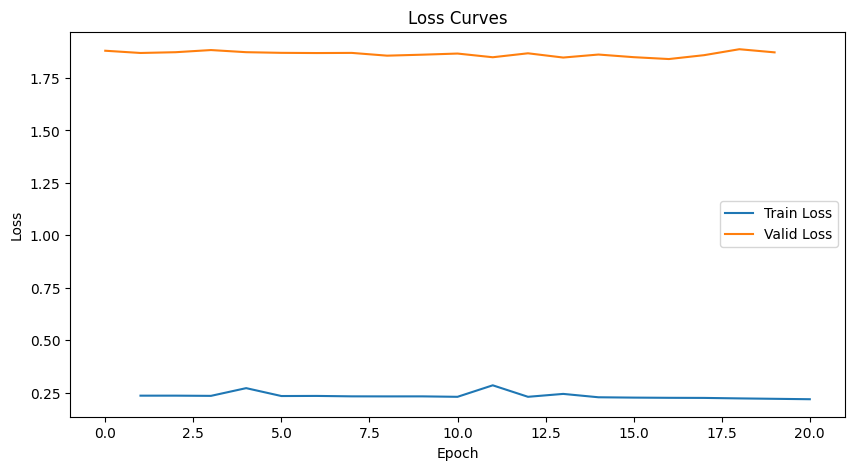

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_loss_history, label="Train Loss")
plt.plot(valid_loss_history, label="Valid Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

In [49]:
torch.save(model.state_dict(), "ncde_model.pth")

In [65]:
model.load_state_dict(torch.load("best_model_interp.pth",map_location=device))

<All keys matched successfully>

In [53]:
test_df = test_df.set_index(['user_id','emotion'])

In [66]:
test_loss = 0
test_classify_loss=0
for (input_seq, ts), (target_ts, target_seq, target_mask), emotion in test_loader:
    # Move inputs to selected device
    input_seq = input_seq.to(device)
    ts = ts.squeeze(0).to(device)

    target_seq, target_mask = target_seq.to(device), target_mask.to(device)
    target_ts = target_ts.squeeze(0).to(device)
    emotion = torch.tensor(le.transform(emotion), dtype=torch.long,device=device)

    coeffs = torchcde.hermite_cubic_coefficients_with_backward_differences(input_seq,t=ts)

    model.eval()
    with torch.no_grad():
        output,emotion_prob = model(coeffs,ts, target_ts)
        #output = model(coeffs,ts, target_ts)
        loss = criterion(output[target_mask], target_seq[target_mask])
        test_loss += loss.item()
        test_classify_loss += criterion2(emotion_prob,emotion).item()
test_loss /= len(test_loader)
test_classify_loss /= len(test_loader)

print(f"Test Loss: {test_loss}, Test Classify Loss: {test_classify_loss}")

Test Loss: 0.09998938627541065, Test Classify Loss: 1.791374408536487


In [67]:
spline_interp = pd.read_csv("E:/CoDaS Project/Radar/C3/radar_interpolated_merged_data.csv", 
                            usecols=['timestamp', 'user_id', 'emotion'])
end_time = spline_interp.groupby(['user_id', 'emotion']).max()

nn_interpolated_data = []
emotion_labels = []
emotion_predictions = []
# Interpolate for each experiment in the test dataset using entire sequence

model.eval()
for experiment in test_dataset.experiments:
    user_id, class_key = experiment
    sync_end = end_time.loc[experiment]['timestamp']
    interp_timestamps = np.arange(0, sync_end, step=spf)
    interp_timestamps = torch.tensor(interp_timestamps, dtype=torch.float32)


    input_sequence = test_df.loc[experiment].groupby("timestamp", as_index=False).mean()

    input_sequence, input_timestamps, mean, std = process_input_sequence(input_sequence)


    input_sequence = input_sequence.unsqueeze(0).to(device)  # Add batch dimension
    input_timestamps = input_timestamps.to(device)  # Input timestamps doesn't need batch dimension
    interp_timestamps = interp_timestamps.to(device)  # Add batch dimension

    coeffs = torchcde.hermite_cubic_coefficients_with_backward_differences(input_sequence,t=input_timestamps)
    
    with torch.no_grad():
        pred, emotion_prob = model(coeffs, input_timestamps, interp_timestamps)  # Remove batch dimension
        pred = pred.squeeze(0)  # Remove batch dimension
        emotion_prob = emotion_prob.squeeze(0)  # Remove batch dimension

    #pred = pred.cpu().numpy() * (std.values + eps) + mean.values  # Denormalize the predictions
    pred = pred.cpu().numpy() + mean.values  # Denormalize the predictions

    emotion_prob = torch.argmax(emotion_prob, dim=-1).item()
    pred_emotion = le.inverse_transform([emotion_prob])[0]

    pred = np.concatenate([interp_timestamps.unsqueeze(-1).cpu().numpy(), pred], axis=-1)
    interp_df = pd.DataFrame(pred, columns=test_df.columns)
    
    interp_df.insert(0, 'user_id', user_id)
    interp_df.insert(1, 'emotion', class_key)

    nn_interpolated_data.append(interp_df)

    emotion_labels.append(class_key)
    emotion_predictions.append(pred_emotion)
    
radar_interp_df = pd.concat(nn_interpolated_data, ignore_index=False)
radar_interp_df.to_csv("E:/CoDaS Project/Radar/C3/radar_nn_test_interpolated_data.csv", index=False)

In [68]:
print("accuracy:", np.mean(np.array(emotion_labels) == np.array(emotion_predictions)))

accuracy: 0.2222222222222222


Text(0.5, 1.0, 'Confusion Matrix for XGBoost Classifier')

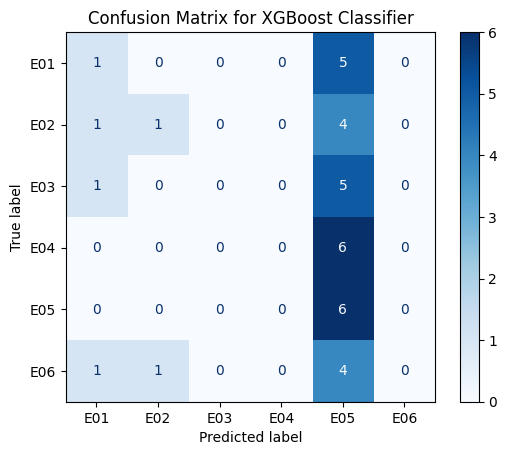

In [69]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(emotion_labels, emotion_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for XGBoost Classifier")